# 各 channel 的 fire 活動分析

對已訓練好的 checkpoint 的某個 epoch 權重快照,做逐 channel、逐神經元的
spike 活動分析:哪個 channel 平均比較活躍、逐神經元的活動量分布長什麼樣子、
活躍程度在空間上怎麼分布。

背景見 [`../../docs/math/剪枝推導.md`](../../docs/math/剪枝推導.md)「為什麼用
活動量不用權重量級」;待辦範圍見 [`../../docs/TODO.md`](../../docs/TODO.md)。

跟 `example/replay_epoch.py` 共用同一套「強制 `chunk_size=1` 精確重跑」的
infra(直接重跑 forward,不是讀 `metrics.csv`)。三塊分析(長條圖/histogram/
空間熱圖)共用同一次逐樣本重跑的結果,不各自重算一次 forward。

In [1]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np

from data.src.nmnist import NMNISTDataset
from example.paths import DATASET_ROOT, EXPERIMENTS_DIR
from example.replay_epoch import load_epoch_weights
from example.utils import TRAIN_DIRNAME, load_run_record
from salt_core.layers import ConvLayer
from salt_core.network import RawEvents
from IPython.display import display
from viz.channel_grid import ImageGridPlot
from viz.style import apply_style

apply_style()

## 參數

改這裡,不改函式庫。

In [2]:
RUN_NAME = "scale_10k_20260919_050446"
EXP_DIR = EXPERIMENTS_DIR / RUN_NAME  # 絕對路徑,跟 kernel 的工作目錄無關
CHANNEL_STATS_EPOCH = 59          # 要有對應的 weights/epoch_XXX.npz
CHANNEL_STATS_N_SAMPLES = 100
CHANNEL_STATS_SPLIT = "train"     # "train" 或 "val"

## 載入 checkpoint、逐樣本重跑 forward

第一筆要等 JIT compile(約 10 秒),之後每筆約 0.6 秒,`CHANNEL_STATS_N_SAMPLES=100`
全部跑完約 70 秒。迴圈裡一次收三種累加量:每個 channel 的平均 spike 數
(長條圖用)、每個神經元的總 spike 數攤回 `(h, w)` 的網格(histogram 跟空間
熱圖共用這份,不重算)。

In [3]:
run_record = load_run_record(EXP_DIR)
data_cfg = run_record["config"]["data"]
dataset = NMNISTDataset(DATASET_ROOT, max_events=data_cfg["max_events"])
n_pool = data_cfg["train_size"] if CHANNEL_STATS_SPLIT == "train" else data_cfg["val_size"]
seed = data_cfg["seed_train"] if CHANNEL_STATS_SPLIT == "train" else data_cfg["seed_val"]
split = dataset.build_split(seed=seed, n_samples=n_pool, which=CHANNEL_STATS_SPLIT)

channel_stats_network, channel_stats_params = load_epoch_weights(EXP_DIR, CHANNEL_STATS_EPOCH)
channel_stats_layers = channel_stats_network.layers
conv_layers = [l for l in channel_stats_layers if isinstance(l, ConvLayer)]

n_use = min(CHANNEL_STATS_N_SAMPLES, n_pool)
per_channel_totals = {l.name: np.zeros(l.oc) for l in conv_layers}
per_neuron_totals = {l.name: np.zeros((l.oc, l.h_out, l.w_out)) for l in conv_layers}

for i in range(n_use):
    sample = (split.event_times[i], split.x[i], split.y[i], split.c[i], split.n_real_events[i])
    traces = channel_stats_network.apply(channel_stats_params, RawEvents.checked(*sample),
                                         trace=True).traces
    for layer, trace in zip(channel_stats_layers, traces):
        if layer.name not in per_channel_totals:
            continue
        per_neuron = np.asarray(trace.spike_mask).sum(axis=1)  # (n,)
        per_neuron_grid = layer.unflatten_neurons(per_neuron)
        per_neuron_totals[layer.name] += per_neuron_grid
        per_channel_totals[layer.name] += per_neuron_grid.sum(axis=(1, 2))
    if (i + 1) % 20 == 0:
        print(f"{i + 1}/{n_use}")

for layer in conv_layers:
    totals = per_channel_totals[layer.name] / n_use
    print(f"\n[{layer.name}] 每筆樣本平均 spike 數(逐 channel):")
    for ch, v in enumerate(totals):
        print(f"  ch{ch:2d}: {v:.1f}")
    print(f"  總和={totals.sum():.1f}  最大/最小={totals.max():.1f}/{totals.min():.1f}  "
          f"標準差={totals.std():.1f}")

20/100
40/100
60/100
80/100
100/100

[conv1] 每筆樣本平均 spike 數(逐 channel):
  ch 0: 568.3
  ch 1: 746.7
  ch 2: 82.5
  ch 3: 314.7
  ch 4: 68.6
  ch 5: 221.6
  ch 6: 390.7
  ch 7: 170.5
  總和=2563.7  最大/最小=746.7/68.6  標準差=223.7

[conv2] 每筆樣本平均 spike 數(逐 channel):
  ch 0: 171.1
  ch 1: 90.7
  ch 2: 99.4
  ch 3: 91.5
  ch 4: 132.7
  ch 5: 124.6
  ch 6: 96.2
  ch 7: 27.6
  ch 8: 97.7
  ch 9: 86.1
  ch10: 47.0
  ch11: 33.0
  ch12: 83.2
  ch13: 61.9
  ch14: 95.3
  ch15: 35.2
  總和=1373.1  最大/最小=171.1/27.6  標準差=37.4


## 逐 channel 長條圖

docs/問題紀錄.md「解法驗證(2026-09-18):weight_decay + 餘弦退火是目前最佳組合,score_cap 沒有幫助」「conv2 spike 變多(lr=1e-3 vs lr=1e-2)」的觀察:
`replay_animation.ipynb` 的動畫只能看單一 sample、看不出來是集中在少數
channel 還是全部一起長,這裡改成多筆樣本累加,把每個 channel 的總 spike 數
量化成長條圖直接回答這個問題。

findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.


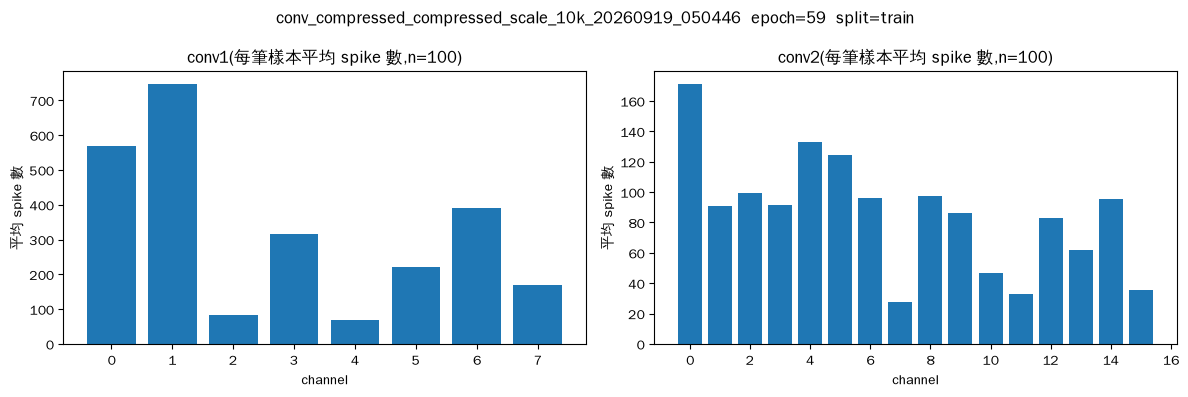

In [4]:
channel_stats_fig, channel_stats_axes = plt.subplots(1, len(conv_layers), figsize=(6 * len(conv_layers), 4))
if len(conv_layers) == 1:
    channel_stats_axes = [channel_stats_axes]
for ax, layer in zip(channel_stats_axes, conv_layers):
    totals = per_channel_totals[layer.name] / n_use
    ax.bar(np.arange(layer.oc), totals)
    ax.set_title(f"{layer.name}(每筆樣本平均 spike 數,n={n_use})")
    ax.set_xlabel("channel")
    ax.set_ylabel("平均 spike 數")
channel_stats_fig.suptitle(f"{RUN_NAME}  epoch={CHANNEL_STATS_EPOCH}  split={CHANNEL_STATS_SPLIT}")
channel_stats_fig.tight_layout()
channel_stats_fig

In [5]:
channel_stats_out_path = os.path.join(
    EXP_DIR, TRAIN_DIRNAME, f"channel_spike_stats_epoch{CHANNEL_STATS_EPOCH}.png")
channel_stats_fig.savefig(channel_stats_out_path, dpi=150)
print(f"寫入 {channel_stats_out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_scale_10k_20260919_050446/train/channel_spike_stats_epoch59.png


## 逐神經元 spike 數分布(histogram)

x 軸是「這個神經元在 N 筆樣本裡累加的總 spike 數」——長條圖看到的是 channel
內平均值,這裡才看得出來同一個 channel 內是均勻分布還是少數位置撐起平均值。
`spike 數 = 0` 的精確個數直接印在子圖標題,不靠 bin 的視覺解析度去猜。

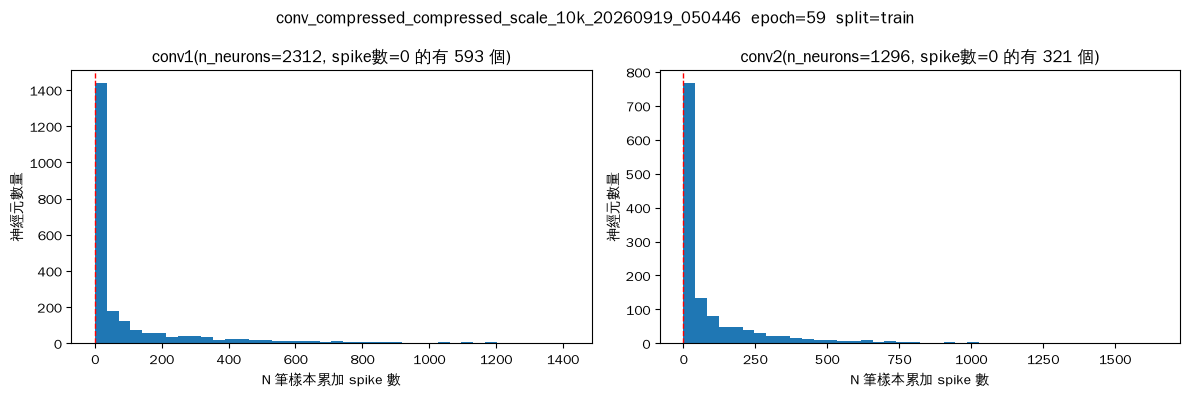

In [6]:
hist_fig, hist_axes = plt.subplots(1, len(conv_layers), figsize=(6 * len(conv_layers), 4))
if len(conv_layers) == 1:
    hist_axes = [hist_axes]
for ax, layer in zip(hist_axes, conv_layers):
    counts = per_neuron_totals[layer.name].ravel()
    n_dead = int(np.sum(counts == 0))
    ax.hist(counts, bins=40)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{layer.name}(n_neurons={counts.size}, spike數=0 的有 {n_dead} 個)")
    ax.set_xlabel("N 筆樣本累加 spike 數")
    ax.set_ylabel("神經元數量")
hist_fig.suptitle(f"{RUN_NAME}  epoch={CHANNEL_STATS_EPOCH}  split={CHANNEL_STATS_SPLIT}")
hist_fig.tight_layout()
hist_fig

In [7]:
hist_out_path = os.path.join(
    EXP_DIR, TRAIN_DIRNAME, f"channel_activity_hist_epoch{CHANNEL_STATS_EPOCH}.png")
hist_fig.savefig(hist_out_path, dpi=150)
print(f"寫入 {hist_out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_scale_10k_20260919_050446/train/channel_activity_hist_epoch59.png


## 空間熱圖

把每個神經元「N 筆樣本的平均 spike 數」還原回 `(h, w)`,每個 channel 一張圖
——看低活動的神經元是不是集中在特定空間位置(例如圖片邊緣,事件本來就稀疏
的地方),還是散布在整個 feature map。集中在邊緣比較可能是資料幾何的正常
現象,散布在各處才比較像是這個 channel 本身有問題。

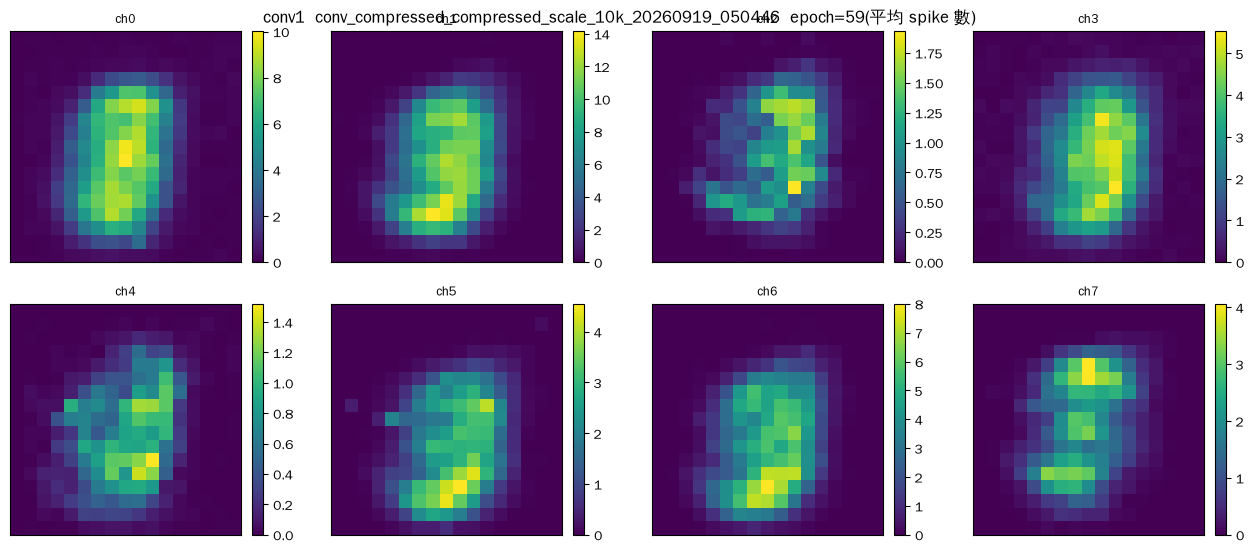

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_scale_10k_20260919_050446/train/channel_activity_map_conv1_epoch59.png


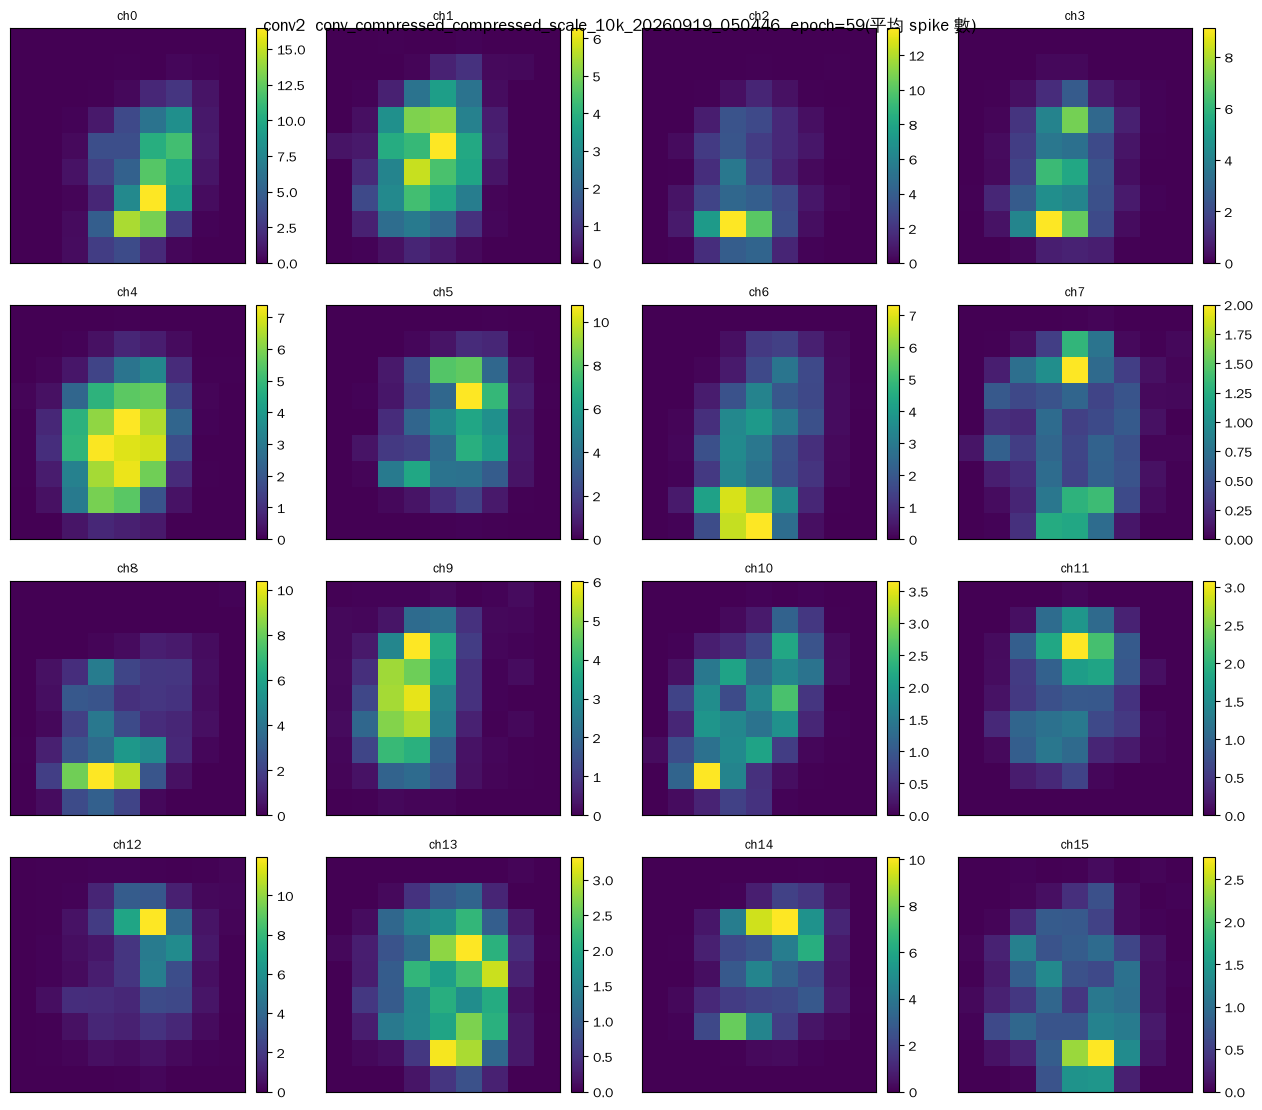

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_scale_10k_20260919_050446/train/channel_activity_map_conv2_epoch59.png


In [9]:
for layer in conv_layers:
    avg_grid = per_neuron_totals[layer.name] / n_use  # (oc, h, w)
    images = [avg_grid[c] for c in range(layer.oc)]
    titles = [f"ch{c}" for c in range(layer.oc)]
    grid_fig = ImageGridPlot(ncols=4).render(images, titles=titles)
    grid_fig.suptitle(f"{layer.name}  {RUN_NAME}  epoch={CHANNEL_STATS_EPOCH}(平均 spike 數)")
    display(grid_fig)
    out_path = os.path.join(
        EXP_DIR, TRAIN_DIRNAME, f"channel_activity_map_{layer.name}_epoch{CHANNEL_STATS_EPOCH}.png")
    grid_fig.savefig(out_path, dpi=150)
    print(f"寫入 {out_path}")